In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = {
    "Size_sqft": [
        800, 900, 1000, 1100, 1200,
        1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2100, 2200,
        2300, 2400, 2500, 2600, 2700
    ],
    
    "Bedrooms": [
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4,
        4, 4, 4, 4, 5
    ],
    
    "Age_years": [
        20, 18, 15, 14, 12,
        10, 9, 8, 7, 6,
        5, 5, 4, 4, 3,
        3, 2, 2, 1, 1
    ],
    
    "Price_lakhs": [
        40, 44, 48, 52, 58,
        62, 67, 71, 76, 81,
        86, 90, 96, 101, 106,
        112, 117, 123, 128, 135
    ]
}

df = pd.DataFrame(data)

df.head()

,Size_sqft,Bedrooms,Age_years,Price_lakhs
0,800,2,20,40
1,900,2,18,44
2,1000,2,15,48
3,1100,2,14,52
4,1200,3,12,58


In [4]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (20, 4)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Size_sqft    20 non-null     int64
 1   Bedrooms     20 non-null     int64
 2   Age_years    20 non-null     int64
 3   Price_lakhs  20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None

Missing Values:
Size_sqft      0
Bedrooms       0
Age_years      0
Price_lakhs    0
dtype: int64

Statistical Summary:
         Size_sqft   Bedrooms  Age_years  Price_lakhs
count    20.000000  20.000000  20.000000    20.000000
mean   1750.000000   3.250000   7.450000    84.650000
std     591.607978   0.850696   5.707567    29.403321
min     800.000000   2.000000   1.000000    40.000000
25%    1275.000000   3.000000   3.000000    61.000000
50%    1750.000000   3.000000   5.500000    83.500000
75%    2225.000000   4.000000  10.500000   107.500000
max    2700.000000   5.0

In [5]:
X = df[["Size_sqft"]]
y = df["Price_lakhs"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Size_sqft
0        800
1        900
2       1000
3       1100
4       1200

Target:
0    40
1    44
2    48
3    52
4    58
Name: Price_lakhs, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=11
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (16, 1)
Testing data: (4, 1)
Training target: (16,)
Testing target: (4,)


In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Model training completed!
Coefficient: 0.04954132410212029
Intercept: -1.9071830376460355


In [10]:
y_pred = model.predict(X_test)

print("Actual Prices:")
print(y_test.values)

print("\nPredicted Prices:")
print(y_pred)

Actual Prices:
[52 62 86 67]

Predicted Prices:
[52.58827347 62.4965383  87.26720035 67.45067071]


In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Model Evaluation
-----------------
Mean Absolute Error: 0.7006707053223682
Mean Squared Error: 0.6003791903752269
Root Mean Squared Error: 0.7748413969163154
R2 Score: 0.9960679217986068


In [12]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(comparison)

   Actual Price  Predicted Price
0            52        52.588273
1            62        62.496538
2            86        87.267200
3            67        67.450671


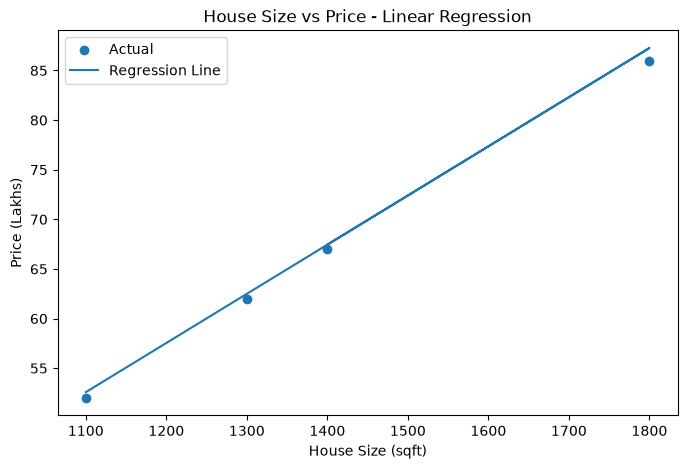

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("House Size (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("House Size vs Price - Linear Regression")

plt.legend()
plt.show()

In [14]:
X_multi = df[[
    "Size_sqft",
    "Bedrooms",
    "Age_years"
]]

y = df["Price_lakhs"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=11
)

print("Training data shape:", X_train_multi.shape)
print("Testing data shape:", X_test_multi.shape)

Training data shape: (16, 3)
Testing data shape: (4, 3)


In [15]:
X_multi = df[[
    "Size_sqft",
    "Bedrooms",
    "Age_years"
]]

y = df["Price_lakhs"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=11
)

print("Training data shape:", X_train_multi.shape)
print("Testing data shape:", X_test_multi.shape)

Training data shape: (16, 3)
Testing data shape: (4, 3)


In [16]:
y_pred_multi = multi_model.predict(X_test_multi)

print("Actual Prices:")
print(y_test_multi.values)

print("\nPredicted Prices:")
print(y_pred_multi)

NameError: name 'multi_model' is not defined

In [17]:
X_multi = df[[
    "Size_sqft",
    "Bedrooms",
    "Age_years"
]]

y = df["Price_lakhs"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=11
)

multi_model = LinearRegression()

multi_model.fit(
    X_train_multi,
    y_train_multi
)

print("Multiple Linear Regression training completed!")

Multiple Linear Regression training completed!


In [18]:
X_multi = df[[
    "Size_sqft",
    "Bedrooms",
    "Age_years"
]]

y = df["Price_lakhs"]

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=11
)

multi_model = LinearRegression()

multi_model.fit(
    X_train_multi,
    y_train_multi
)

print("Multiple Linear Regression training completed!")

Multiple Linear Regression training completed!


In [19]:
y_pred_multi = multi_model.predict(X_test_multi)

print("Actual Prices:")
print(y_test_multi.values)

print("\nPredicted Prices:")
print(y_pred_multi)

Actual Prices:
[52 62 86 67]

Predicted Prices:
[52.28044062 61.26328089 85.11023238 66.03267119]


In [20]:
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("Multiple Feature Model Evaluation")
print("----------------------------------")
print("MAE:", mae_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R2 Score:", r2_multi)

Multiple Feature Model Evaluation
----------------------------------
MAE: 0.7185640384749306
MSE: 0.5872033556626911
RMSE: 0.7662919519756756
R2 Score: 0.996154214617027


In [21]:
comparison_results = pd.DataFrame({
    "Model": [
        "Size Only",
        "Size + Bedrooms + Age"
    ],
    "MAE": [
        mae,
        mae_multi
    ],
    "RMSE": [
        rmse,
        rmse_multi
    ],
    "R2 Score": [
        r2,
        r2_multi
    ]
})

comparison_results

,Model,MAE,RMSE,R2 Score
0,Size Only,0.700671,0.774841,0.996068
1,Size + Bedrooms + Age,0.718564,0.766292,0.996154


In [22]:
new_house = pd.DataFrame({
    "Size_sqft": [2000],
    "Bedrooms": [4],
    "Age_years": [5]
})

predicted_price = multi_model.predict(new_house)

print(f"Predicted House Price: {predicted_price[0]:.2f} Lakhs")

Predicted House Price: 97.27 Lakhs


In [23]:
coefficients = pd.DataFrame({
    "Feature": X_multi.columns,
    "Coefficient": multi_model.coef_
})

print(coefficients)

print("\nIntercept:", multi_model.intercept_)

     Feature  Coefficient
0  Size_sqft     0.055644
1   Bedrooms     1.034083
2  Age_years     0.795012

Intercept: -22.126316481849685
